In [17]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import sin, radians 
from uncertainties.umath import *

In [18]:
# 1. Auflösungsvermögen eines Gitters

#Wellenlängen der gelben Doppellinie und andere Konstanten
lambda_1 = 576.96           #[nm]
lambda_2 = 579.07           #[nm]
delta_lambda = lambda_2 -lambda_1           #[nm]

A = lambda_1/delta_lambda                   #Auflösungsvermögen; einheitslos
print(f"Auflösungsvermögen: A = {A}")
print()

#Formel Gitterkonstante
def gitter(n, B, A):
    g = (n * B)/A
    return g

#Blendenbreiten nach rechts und links; jeweils bis 3 neben Hauptmaximum
b_r = unp.uarray([1.3, 1.1, 0.55], 0.05)          #[mm]
b_l = unp.uarray([1.3, 0.7, 0.34], 0.05)          #[mm]

n = np.array([2, 3, 4])             #Ordnung der Maxima

#Berechnung der Gitterkonstanten
d_r = gitter(n, b_r, A)             #Gitterkonstaten von der rechten Seite; [mm]
g_r = np.sum(d_r)/3                         #Mittelwert von rechts; [mm]
print(f"gitter rechts: {d_r}")

d_l = gitter(n, b_l, A)             #Gitterkonstanten von der linken Seite; [mm]
g_l = np.sum(d_l)/3                         #Mittelwert von links; [mm]
print(f"gitter links: {d_l}")

g = (g_r + g_l)/2                   #Gitterkonstante (Mittelwert aus den Werten von rechts und links); [mm]

g_werte = np.array([unp.nominal_values(d_r), unp.nominal_values(d_l)])
g_mean = np.mean(g_werte)
g_std = np.std(g_werte, ddof=1)/np.sqrt(len(g_werte))

#Ergebinisse printen
print()
print(f"Mittelwert Gitter rechts: g_r = {g_r} mm")
print(f"Mittelwert Gitter links: g_l = {g_l} mm")
print(f"Gitterkonstante: g = {g} mm")
print()
print(f"g mit standardabweichung als unsicherheit: g = {g_mean} +/- {g_std}")



Auflösungsvermögen: A = 273.4407582938371

gitter rechts: [0.009508458125346706+/-0.0003657099278979502
 0.012068427620632358+/-0.0005485648918469253
 0.008045618413754905+/-0.0007314198557959004]
gitter links: [0.009508458125346706+/-0.0003657099278979502
 0.007679908485856953+/-0.0005485648918469253
 0.004973655019412123+/-0.0007314198557959004]

Mittelwert Gitter rechts: g_r = 0.00987+/-0.00033 mm
Mittelwert Gitter links: g_l = 0.00739+/-0.00033 mm
Gitterkonstante: g = 0.00863+/-0.00023 mm

g mit standardabweichung als unsicherheit: g = 0.008630754298391625 +/- 0.001672698203058924


In [19]:
# 2. Spektroskopie

#anscheinend nur screenshots von auswertungen mit OceanView - Kein Code?
#evtl doch was mit csv datein und plotten? --> fragen ob screenshot oder lieber plot mit csv aber sollt easy sein


Ausdehnungskoeffizient: alpha  = (2.58+/-0.07)e-05 1/K


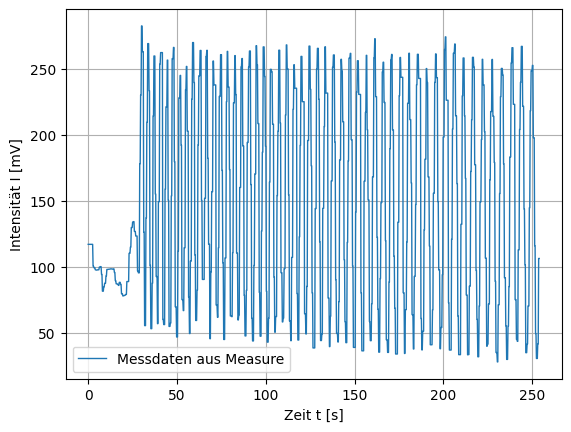

In [20]:
# 3. Michelson-Interferometer

#Werte:
T_s = ufloat(23.3, 0.1)         #[°C]; Starttemperatur, Unsicherheit = Auflösung
T_e = ufloat(30.1, 0.1)         #[°C]; endtemperatur
delta_T = T_e -T_s          #[°C]

lambda_ = ufloat(632.8, 0.1)        #[nm]; Wellenlänge Laser

l0 = ufloat(9*10**7, 10**6)             #[nm]; Länge Stab (umrechnen in nm für leichteres rechnen später!!)

N = ufloat(50*2, 1)             #Abgesählte Vielfache von pi-SChwingungen


#Measure Werte auslesen und Ausdehnungskoeffizient:
Data = pd.read_csv("michelson_Do01_160426.csv", sep=',', decimal='.')
t = Data["t"].to_numpy()         #Zeit aus csv [s]
I = Data["I"].to_numpy()         #Intensität aus csv [mV]

alpha = (N * lambda_) / (4 * l0 * delta_T)      #Ausdehnungskoeffizient [1/K]
print(f"Ausdehnungskoeffizient: alpha  = {alpha} 1/K")


#Plot
plt.figure()
plt.plot(t, I , '-', linewidth=1, label="Messdaten aus Measure")
plt.xlabel("Zeit t [s]")
plt.ylabel("Intensität I [mV]")
plt.grid(True)
plt.legend()
plt.show()
